In [ ]:
from __future__ import annotations
import glob
import os
from dataclasses import dataclass, field

import numpy as np
import xarray as xr
from scipy import ndimage

# ---------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------

# Candidate variable names for cloud-top / brightness temperature in
# MOSDAC cloud products -- adjust once you inspect an actual file with
# `ncdump -h file.nc` or `xr.open_dataset(file).data_vars`.
CTT_VARNAMES = ["CTT", "cloud_top_temp", "Tb", "brightness_temperature"]

# Threshold (Kelvin) for "cold cloud" -- WD-associated frontal cloud
# bands are typically colder than ~233 K (-40 C) at the core, but a
# looser threshold (~250 K) helps catch the broader cloud shield.
COLD_THRESHOLD_K = 250.0

# Minimum cluster size (in grid cells) to filter out small noise
MIN_CLUSTER_SIZE = 15

# Max allowed centroid displacement (degrees) between consecutive
# time steps to still be considered "the same" system. WDs move at
# roughly 5-15 deg longitude/day under the westerly jet; adjust to
# your data's time resolution.
MAX_LINK_DISTANCE_DEG = 6.0


# ---------------------------------------------------------------------
# Data structures
# ---------------------------------------------------------------------

@dataclass
class Cluster:
    time: np.datetime64
    lat: float          # centroid latitude
    lon: float           # centroid longitude
    min_ctt: float        # coldest pixel in cluster (K)
    n_pixels: int          # cluster size
    source: str              # 'meteosat8' or 'insat3d'


@dataclass
class Track:
    clusters: list[Cluster] = field(default_factory=list)

    def append(self, c: Cluster):
        self.clusters.append(c)

    @property
    def path(self):
        return [(c.lat, c.lon) for c in self.clusters]

    def speed_deg_per_step(self):
        """Rough propagation speed between consecutive points (deg/step)."""
        speeds = []
        for a, b in zip(self.clusters[:-1], self.clusters[1:]):
            d = np.hypot(b.lat - a.lat, b.lon - a.lon)
            speeds.append(d)
        return speeds


# ---------------------------------------------------------------------
# Stage 1: cluster detection on a single time-slice
# ---------------------------------------------------------------------

def find_ctt_var(ds: xr.Dataset) -> str:
    for name in CTT_VARNAMES:
        if name in ds.data_vars:
            return name
    raise ValueError(
        f"No known CTT variable found. Available vars: {list(ds.data_vars)}"
    )


def detect_clusters(lat2d: np.ndarray, lon2d: np.ndarray, ctt: np.ndarray,
                     time: np.datetime64, source: str) -> list[Cluster]:
    """Threshold + connected-component labeling to find cold cloud clusters."""
    mask = ctt < COLD_THRESHOLD_K
    labeled, n = ndimage.label(mask)

    clusters = []
    for label_id in range(1, n + 1):
        ys, xs = np.where(labeled == label_id)
        if len(ys) < MIN_CLUSTER_SIZE:
            continue
        clat = float(lat2d[ys, xs].mean())
        clon = float(lon2d[ys, xs].mean())
        min_ctt = float(ctt[ys, xs].min())
        clusters.append(Cluster(
            time=time, lat=clat, lon=clon,
            min_ctt=min_ctt, n_pixels=len(ys), source=source,
        ))
    return clusters


def clusters_from_file(path: str, source: str) -> list[Cluster]:
    ds = xr.open_dataset(path)
    varname = find_ctt_var(ds)
    ctt = ds[varname].values
    lat = ds["latitude"].values if "latitude" in ds else ds["lat"].values
    lon = ds["longitude"].values if "longitude" in ds else ds["lon"].values
    if lat.ndim == 1:
        lon2d, lat2d = np.meshgrid(lon, lat)
    else:
        lat2d, lon2d = lat, lon

    time_val = np.datetime64("NaT")
    if "time" in ds:
        # Handle both scalar and 1-D time variables
        if ds["time"].ndim == 0:
            time_val = ds["time"].values
        else:
            time_val = ds["time"].values[0]

    ds.close()
    return detect_clusters(lat2d, lon2d, ctt, time_val, source)


# ---------------------------------------------------------------------
# Stage 2: linking clusters across time steps (incl. sensor handoff)
# ---------------------------------------------------------------------

def link_tracks(all_clusters: list[Cluster]) -> list[Track]:
    """
    Greedy nearest-neighbor tracker: sorts clusters by time, and at each
    step links each active track to the closest unclaimed cluster in the
    next time step (within MAX_LINK_DISTANCE_DEG). This naturally handles
    the meteosat8 -> insat3d handoff since linking is done purely on
    lat/lon proximity, not on `source`.
    """
    by_time: dict[np.datetime64, list[Cluster]] = {}
    for c in all_clusters:
        by_time.setdefault(c.time, []).append(c)
    times = sorted(by_time.keys())

    active_tracks: list[Track] = []
    finished_tracks: list[Track] = []

    for t in times:
        candidates = by_time[t]
        used = set()

        for track in active_tracks:
            last = track.clusters[-1]
            best_idx, best_dist = None, np.inf
            for i, cand in enumerate(candidates):
                if i in used:
                    continue
                d = np.hypot(cand.lat - last.lat, cand.lon - last.lon)
                if d < best_dist:
                    best_dist, best_idx = d, i
            if best_idx is not None and best_dist <= MAX_LINK_DISTANCE_DEG:
                track.append(candidates[best_idx])
                used.add(best_idx)

        # any candidate not claimed starts a new track
        for i, cand in enumerate(candidates):
            if i not in used:
                new_track = Track()
                new_track.append(cand)
                active_tracks.append(new_track)

        # retire tracks that weren't extended this step (simple version:
        # keep them active for now; a production version would drop
        # tracks after N missed steps)

    finished_tracks.extend(active_tracks)
    return finished_tracks


# ---------------------------------------------------------------------
# Pipeline entry point
# ---------------------------------------------------------------------

def run_pipeline(met8_dir: str, insat3d_dir: str) -> list[Track]:
    all_clusters = []
    for path in sorted(glob.glob(os.path.join(met8_dir, "*.nc"))):
        all_clusters.extend(clusters_from_file(path, source="meteosat8"))
    for path in sorted(glob.glob(os.path.join(insat3d_dir, "*.nc"))):
        all_clusters.extend(clusters_from_file(path, source="insat3d"))

    tracks = link_tracks(all_clusters)
    # keep only tracks with a meaningful lifetime (filters noise)
    tracks = [t for t in tracks if len(t.clusters) >= 3]
    return tracks


# ---------------------------------------------------------------------
# Demo on synthetic data (no real files needed)
# ---------------------------------------------------------------------

def _synthetic_demo():
    print("Running synthetic demo (no real MOSDAC files needed)...\n")
    lat = np.linspace(10, 40, 60)
    lon = np.linspace(50, 90, 80)
    lon2d, lat2d = np.meshgrid(lon, lat)

    all_clusters = []
    # simulate a cold cloud blob moving eastward over 6 time steps,
    # crossing from the "meteosat8" domain (lon < 70) into the
    # "insat3d" domain (lon >= 70)
    start_lon = 55
    for step in range(6):
        center_lon = start_lon + step * 5.5
        center_lat = 28 - step * 0.5
        ctt = 280 - 40 * np.exp(-(((lon2d - center_lon) ** 2 +
                                    (lat2d - center_lat) ** 2) / 20))
        source = "meteosat8" if center_lon < 70 else "insat3d"
        time = np.datetime64("2026-01-10") + np.timedelta64(step * 6, "h")
        clusters = detect_clusters(lat2d, lon2d, ctt, time, source)
        all_clusters.extend(clusters)
        print(f"t={time}  source={source:9s}  clusters found={len(clusters)}")

    tracks = link_tracks(all_clusters)
    print(f"\n{len(tracks)} track(s) found after linking\n")
    for i, tr in enumerate(tracks):
        print(f"Track {i}: {len(tr.clusters)} points")
        for c in tr.clusters:
            print(f"    {c.time}  lat={c.lat:.2f}  lon={c.lon:.2f}  " +
                  f"min_ctt={c.min_ctt:.1f}K  src={c.source}")
        speeds = tr.speed_deg_per_step()
        if speeds:
            print(f"    avg propagation speed: {np.mean(speeds):.2f} deg/step\n")


if __name__ == "__main__":
    _synthetic_demo()


Running synthetic demo (no real MOSDAC files needed)...

t=2026-01-10T00  source=meteosat8  clusters found=1
t=2026-01-10T06  source=meteosat8  clusters found=1
t=2026-01-10T12  source=meteosat8  clusters found=1
t=2026-01-10T18  source=insat3d    clusters found=1
t=2026-01-11T00  source=insat3d    clusters found=1
t=2026-01-11T06  source=insat3d    clusters found=1

1 track(s) found after linking

Track 0: 6 points
    2026-01-10T00  lat=27.99  lon=54.98  min_ctt=240.1K  src=meteosat8
    2026-01-10T06  lat=27.48  lon=60.55  min_ctt=240.1K  src=meteosat8
    2026-01-10T12  lat=26.97  lon=66.01  min_ctt=240.2K  src=meteosat8
    2026-01-10T18  lat=26.46  lon=71.46  min_ctt=240.2K  src=insat3d
    2026-01-11T00  lat=25.98  lon=77.01  min_ctt=240.2K  src=insat3d
    2026-01-11T06  lat=25.48  lon=82.48  min_ctt=240.1K  src=insat3d
    avg propagation speed: 5.52 deg/step



### Visualize Generated Tracks

In [ ]:
import matplotlib.pyplot as plt

# Recreate the synthetic demo data to make 'tracks' available
print("Regenerating synthetic track data for visualization...")
lat = np.linspace(10, 40, 60)
lon = np.linspace(50, 90, 80)
lon2d, lat2d = np.meshgrid(lon, lat)

all_clusters_viz = []
start_lon = 55
for step in range(6):
    center_lon = start_lon + step * 5.5
    center_lat = 28 - step * 0.5
    ctt = 280 - 40 * np.exp(-(((lon2d - center_lon) ** 2 +
                                (lat2d - center_lat) ** 2) / 20))
    source = "meteosat8" if center_lon < 70 else "insat3d"
    time = np.datetime64("2026-01-10") + np.timedelta64(step * 6, "h")
    clusters = detect_clusters(lat2d, lon2d, ctt, time, source)
    all_clusters_viz.extend(clusters)

tracks_for_viz = link_tracks(all_clusters_viz)
tracks_for_viz = [t for t in tracks_for_viz if len(t.clusters) >= 3]

print(f"\n{len(tracks_for_viz)} track(s) available for visualization.")

Regenerating synthetic track data for visualization...

1 track(s) available for visualization.


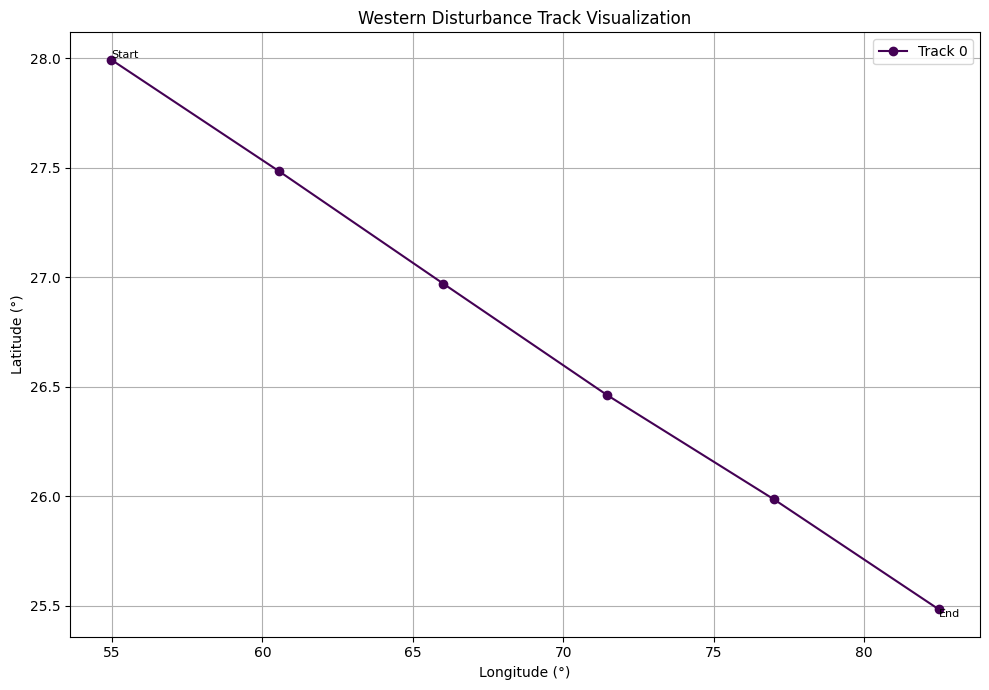

In [ ]:
# Plotting the tracks
fig, ax = plt.subplots(figsize=(10, 7))

# Updated to correctly use plt.colormaps.get_cmap for Matplotlib 3.7+ compatibility
# Get the colormap object
cmap = plt.colormaps.get_cmap('viridis')

num_tracks = len(tracks_for_viz)
# Create a normalized array for indexing the colormap
if num_tracks > 0:
    norm_indices = np.linspace(0, 1, num_tracks)
else:
    norm_indices = [] # Handle case with no tracks

for i, track in enumerate(tracks_for_viz):
    lats = [c.lat for c in track.clusters]
    lons = [c.lon for c in track.clusters]
    times = [c.time for c in track.clusters]

    # Use the colormap with the normalized index
    color = cmap(norm_indices[i])
    ax.plot(lons, lats, marker='o', linestyle='-', color=color, label=f'Track {i}')

    # Annotate start and end points
    if len(lats) > 0:
        ax.text(lons[0], lats[0], 'Start', fontsize=8, verticalalignment='bottom')
        ax.text(lons[-1], lats[-1], 'End', fontsize=8, verticalalignment='top')

ax.set_title('Western Disturbance Track Visualization')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

### Simulating a Two-Source Scenario with Synthetic NetCDF Files

In [ ]:
import tempfile
import shutil

# Define temporary directories for Meteosat-8 and INSAT-3D data
met8_temp_dir = tempfile.mkdtemp()
insat3d_temp_dir = tempfile.mkdtemp()

print(f"Meteosat-8 temporary directory: {met8_temp_dir}")
print(f"INSAT-3D temporary directory: {insat3d_temp_dir}")

# Define the spatial grid
lat = np.linspace(10, 40, 60)
lon = np.linspace(50, 90, 80)
lon2d, lat2d = np.meshgrid(lon, lat)

# Simulate a cold cloud blob moving eastward over 6 time steps
start_lon = 55

for step in range(6):
    center_lon = start_lon + step * 5.5
    center_lat = 28 - step * 0.5

    # Generate a synthetic CTT field
    ctt_data = 280 - 40 * np.exp(-(((lon2d - center_lon) ** 2 +
                                   (lat2d - center_lat) ** 2) / 20))

    # Determine the source and save to the respective directory
    current_source = "meteosat8" if center_lon < 70 else "insat3d"
    output_dir = met8_temp_dir if current_source == "meteosat8" else insat3d_temp_dir

    # Define time for the current step
    time_val = np.datetime64("2026-01-10T00") + np.timedelta64(step * 6, "h")

    # Create an xarray Dataset
    ds = xr.Dataset(
        {
            "CTT": (("y", "x"), ctt_data),
        },
        coords={
            "latitude": (("y", "x"), lat2d),
            "longitude": (("y", "x"), lon2d),
            "time": time_val,
        }
    )

    # Define filename and save
    filename = os.path.join(output_dir, f"cloud_data_{time_val.astype(str).replace(':', '')}.nc")
    ds.to_netcdf(filename)
    print(f"Generated {filename}")

print("\nSynthetic NetCDF files generated.")

Meteosat-8 temporary directory: /tmp/tmpojgn9guj
INSAT-3D temporary directory: /tmp/tmpaqd5wiv9
Generated /tmp/tmpojgn9guj/cloud_data_2026-01-10T00.nc
Generated /tmp/tmpojgn9guj/cloud_data_2026-01-10T06.nc
Generated /tmp/tmpojgn9guj/cloud_data_2026-01-10T12.nc
Generated /tmp/tmpaqd5wiv9/cloud_data_2026-01-10T18.nc
Generated /tmp/tmpaqd5wiv9/cloud_data_2026-01-11T00.nc
Generated /tmp/tmpaqd5wiv9/cloud_data_2026-01-11T06.nc

Synthetic NetCDF files generated.


In [ ]:
# Now, run the pipeline with the generated data
print("\nRunning the WD tracking pipeline with simulated Meteosat-8 and INSAT-3D data...")
simulated_tracks = run_pipeline(met8_dir=met8_temp_dir, insat3d_dir=insat3d_temp_dir)

print(f"\n{len(simulated_tracks)} track(s) found after running the pipeline.")
for i, tr in enumerate(simulated_tracks):
    print(f"Track {i}: {len(tr.clusters)} points")
    for c in tr.clusters:
        print(f"    {c.time}  lat={c.lat:.2f}  lon={c.lon:.2f}  "+
              f"min_ctt={c.min_ctt:.1f}K  src={c.source}")
    speeds = tr.speed_deg_per_step()
    if speeds:
        print(f"    avg propagation speed: {np.mean(speeds):.2f} deg/step\n")

# Clean up temporary directories
shutil.rmtree(met8_temp_dir)
shutil.rmtree(insat3d_temp_dir)
print("Temporary directories cleaned up.")


Running the WD tracking pipeline with simulated Meteosat-8 and INSAT-3D data...

1 track(s) found after running the pipeline.
Track 0: 6 points
    2026-01-10T00:00:00.000000000  lat=27.99  lon=54.98  min_ctt=240.1K  src=meteosat8
    2026-01-10T06:00:00.000000000  lat=27.48  lon=60.55  min_ctt=240.1K  src=meteosat8
    2026-01-10T12:00:00.000000000  lat=26.97  lon=66.01  min_ctt=240.2K  src=meteosat8
    2026-01-10T18:00:00.000000000  lat=26.46  lon=71.46  min_ctt=240.2K  src=insat3d
    2026-01-11T00:00:00.000000000  lat=25.98  lon=77.01  min_ctt=240.2K  src=insat3d
    2026-01-11T06:00:00.000000000  lat=25.48  lon=82.48  min_ctt=240.1K  src=insat3d
    avg propagation speed: 5.52 deg/step

Temporary directories cleaned up.


### Visualizing the Simulated Two-Source Tracks

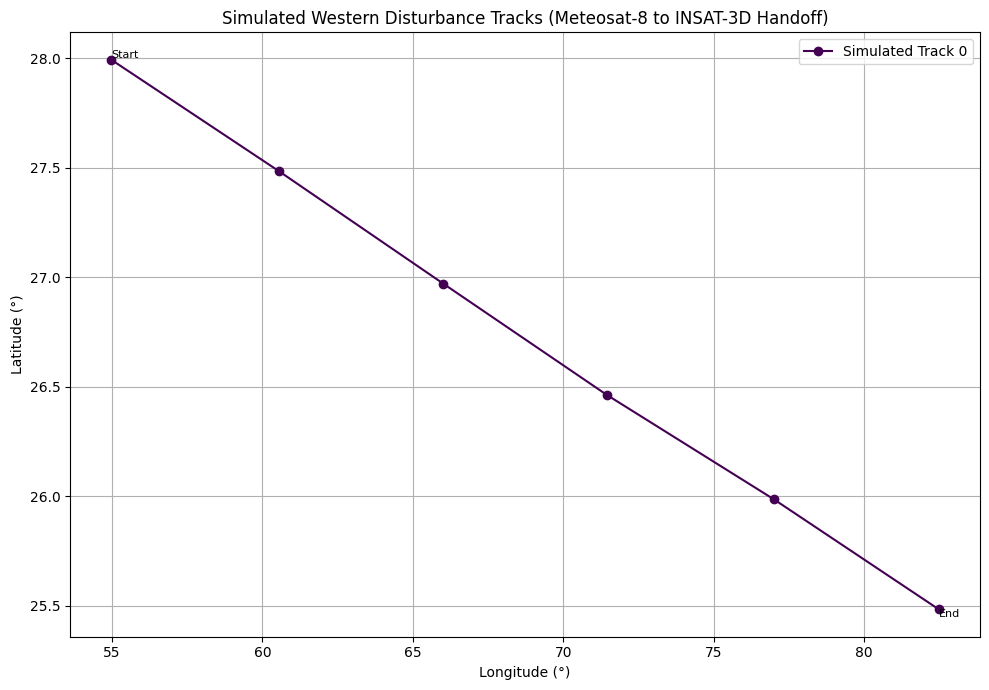

In [ ]:
# Plotting the simulated tracks
fig, ax = plt.subplots(figsize=(10, 7))

cmap = plt.colormaps.get_cmap('viridis')
num_tracks = len(simulated_tracks)

if num_tracks > 0:
    norm_indices = np.linspace(0, 1, num_tracks)
else:
    norm_indices = []

for i, track in enumerate(simulated_tracks):
    lats = [c.lat for c in track.clusters]
    lons = [c.lon for c in track.clusters]

    color = cmap(norm_indices[i])
    ax.plot(lons, lats, marker='o', linestyle='-', color=color, label=f'Simulated Track {i}')

    # Annotate start and end points
    if len(lats) > 0:
        ax.text(lons[0], lats[0], 'Start', fontsize=8, verticalalignment='bottom')
        ax.text(lons[-1], lats[-1], 'End', fontsize=8, verticalalignment='top')

ax.set_title('Simulated Western Disturbance Tracks (Meteosat-8 to INSAT-3D Handoff)')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Now, run the pipeline with the generated data
print("\nRunning the WD tracking pipeline with simulated Meteosat-8 and INSAT-3D data...")
simulated_tracks = run_pipeline(met8_dir=met8_temp_dir, insat3d_dir=insat3d_temp_dir)

print(f"\n{len(simulated_tracks)} track(s) found after running the pipeline.")
for i, tr in enumerate(simulated_tracks):
    print(f"Track {i}: {len(tr.clusters)} points")
    for c in tr.clusters:
        print(f"    {c.time}  lat={c.lat:.2f}  lon={c.lon:.2f}  "+
              f"min_ctt={c.min_ctt:.1f}K  src={c.source}")
    speeds = tr.speed_deg_per_step()
    if speeds:
        print(f"    avg propagation speed: {np.mean(speeds):.2f} deg/step\n")

# Clean up temporary directories
shutil.rmtree(met8_temp_dir)
shutil.rmtree(insat3d_temp_dir)
print("Temporary directories cleaned up.")


Running the WD tracking pipeline with simulated Meteosat-8 and INSAT-3D data...


IndexError: invalid index to scalar variable.

### Visualizing the Simulated Two-Source Tracks

NameError: name 'simulated_tracks' is not defined

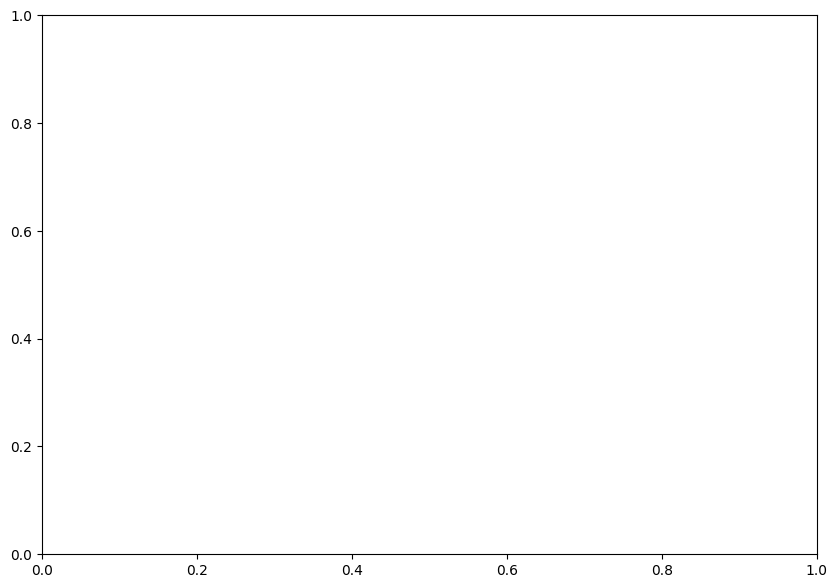

In [ ]:
# Plotting the simulated tracks
fig, ax = plt.subplots(figsize=(10, 7))

cmap = plt.colormaps.get_cmap('viridis')
num_tracks = len(simulated_tracks)

if num_tracks > 0:
    norm_indices = np.linspace(0, 1, num_tracks)
else:
    norm_indices = []

for i, track in enumerate(simulated_tracks):
    lats = [c.lat for c in track.clusters]
    lons = [c.lon for c in track.clusters]

    color = cmap(norm_indices[i])
    ax.plot(lons, lats, marker='o', linestyle='-', color=color, label=f'Simulated Track {i}')

    # Annotate start and end points
    if len(lats) > 0:
        ax.text(lons[0], lats[0], 'Start', fontsize=8, verticalalignment='bottom')
        ax.text(lons[-1], lats[-1], 'End', fontsize=8, verticalalignment='top')

ax.set_title('Simulated Western Disturbance Tracks (Meteosat-8 to INSAT-3D Handoff)')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Now, run the pipeline with the generated data
print("\nRunning the WD tracking pipeline with simulated Meteosat-8 and INSAT-3D data...")
simulated_tracks = run_pipeline(met8_dir=met8_temp_dir, insat3d_dir=insat3d_temp_dir)

print(f"\n{len(simulated_tracks)} track(s) found after running the pipeline.")
for i, tr in enumerate(simulated_tracks):
    print(f"Track {i}: {len(tr.clusters)} points")
    for c in tr.clusters:
        print(f"    {c.time}  lat={c.lat:.2f}  lon={c.lon:.2f}  "+
              f"min_ctt={c.min_ctt:.1f}K  src={c.source}")
    speeds = tr.speed_deg_per_step()
    if speeds:
        print(f"    avg propagation speed: {np.mean(speeds):.2f} deg/step\n")

# Clean up temporary directories
shutil.rmtree(met8_temp_dir)
shutil.rmtree(insat3d_temp_dir)
print("Temporary directories cleaned up.")


Running the WD tracking pipeline with simulated Meteosat-8 and INSAT-3D data...


IndexError: invalid index to scalar variable.

### Visualizing the Simulated Two-Source Tracks

NameError: name 'simulated_tracks' is not defined

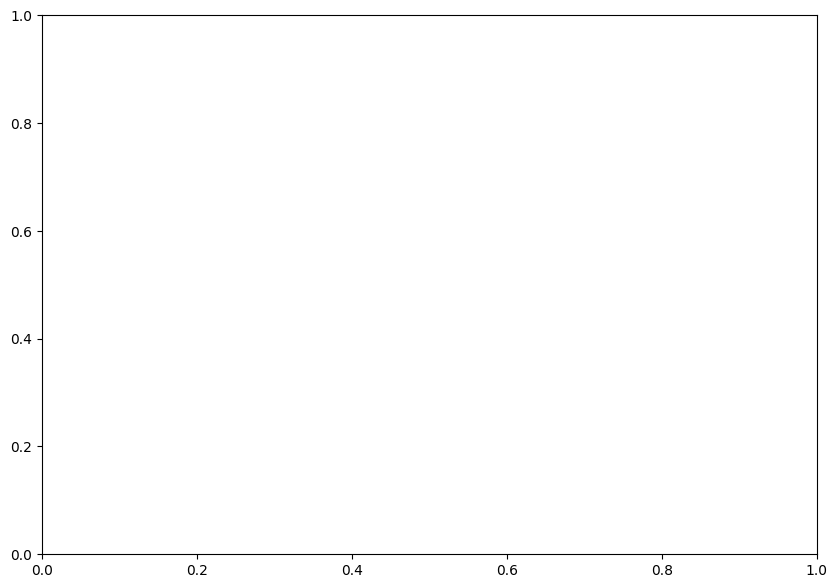

In [ ]:
# Plotting the simulated tracks
fig, ax = plt.subplots(figsize=(10, 7))

cmap = plt.colormaps.get_cmap('viridis')
num_tracks = len(simulated_tracks)

if num_tracks > 0:
    norm_indices = np.linspace(0, 1, num_tracks)
else:
    norm_indices = []

for i, track in enumerate(simulated_tracks):
    lats = [c.lat for c in track.clusters]
    lons = [c.lon for c in track.clusters]

    color = cmap(norm_indices[i])
    ax.plot(lons, lats, marker='o', linestyle='-', color=color, label=f'Simulated Track {i}')

    # Annotate start and end points
    if len(lats) > 0:
        ax.text(lons[0], lats[0], 'Start', fontsize=8, verticalalignment='bottom')
        ax.text(lons[-1], lats[-1], 'End', fontsize=8, verticalalignment='top')

ax.set_title('Simulated Western Disturbance Tracks (Meteosat-8 to INSAT-3D Handoff)')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()